In [3]:
#Import tools 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# A/B Testing + Statistical Analysis Project

In [4]:
#Load your data file

df = pd.read_csv("D:/TopMentor/Projects/AB Testing/ab_data.csv")


In [5]:
# Show first few rows 

df.head()

,user_id,timestamp,group,landing_page,conversion
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1


In [6]:
# Show info of data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   conversion    294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [7]:
# Make all column names simple (lowercase)

df.columns = df.columns.str.lower().str.strip()

In [8]:
# Check column names

df.columns

Index(['user_id', 'timestamp', 'group', 'landing_page', 'conversion'], dtype='object')

 Verify Randomization

In [22]:
pd.crosstab(df['group'], df['landing_page'])

landing_page,new_page,old_page
group,,
control,0,145274
treatment,145310,0


In [19]:
df = df[((df['group'] == 'control') & (df['landing_page'] == 'old_page')) |
            ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))]

In [20]:
# Remove duplicates
df = df.drop_duplicates(subset='user_id')

print("Cleaned Data Shape:", df.shape)

Cleaned Data Shape: (290584, 5)


In [21]:
# Count how many users in A and B

df['group'].value_counts()

group
treatment    145310
control      145274
Name: count, dtype: int64

STEP 4: Check Success Rate (Conversion)

In [17]:
# Check success rate of each group

df.groupby('group')['conversion'].mean()

group
control      0.120386
treatment    0.118807
Name: conversion, dtype: float64

In [25]:
# Conversion Rates
# ===============================
control = df[df['group'] == 'control']
treatment = df[df['group'] == 'treatment']

control_cr = control['conversion'].mean()
treatment_cr = treatment['conversion'].mean()

print(f"Control Conversion Rate: {control_cr:.4f}")
print(f"Treatment Conversion Rate: {treatment_cr:.4f}")


Control Conversion Rate: 0.1204
Treatment Conversion Rate: 0.1188


 Chi-Square Test

In [18]:
# Make a table comparing A vs B
table = pd.crosstab(df['group'], df['conversion'])

# Apply statistical test
chi2, p_value, dof, expected = stats.chi2_contingency(table)

print("p-value:", p_value)

p-value: 0.19158976298516003


In [26]:
# Z-Test for Proportions
# ===============================
from statsmodels.stats.proportion import proportions_ztest

conversions = np.array([control['conversion'].sum(), treatment['conversion'].sum()])
n_obs = np.array([len(control), len(treatment)])

z_stat, pval_z = proportions_ztest(conversions, n_obs)

print(f"Z-statistic: {z_stat:.4f}, P-value: {pval_z:.4f}")


Z-statistic: 1.3109, P-value: 0.1899


In [27]:
# Confidence Interval
# ===============================
def proportion_ci(success, n, confidence=0.95):
    p = success / n
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    se = np.sqrt((p * (1 - p)) / n)
    return p - z * se, p + z * se

control_ci = proportion_ci(conversions[0], n_obs[0])
treatment_ci = proportion_ci(conversions[1], n_obs[1])

print(f"Control 95% CI: {control_ci}")
print(f"Treatment 95% CI: {treatment_ci}")


Control 95% CI: (np.float64(0.11871294722381814), np.float64(0.12205966177710426))
Treatment 95% CI: (np.float64(0.11714442856134422), np.float64(0.12047170246886707))


In [29]:
 #Effect Size (Cohen's h)
# ===============================
def cohens_h(p1, p2):
    return 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))

h = cohens_h(control_cr, treatment_cr)

print(f"Cohen's h: {h:.4f}")

Cohen's h: 0.0049


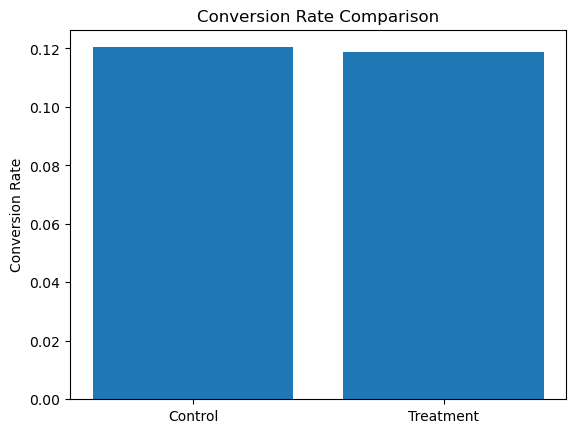

In [30]:
# Visualization
# ===============================
labels = ['Control', 'Treatment']
cr_values = [control_cr, treatment_cr]

plt.figure()
plt.bar(labels, cr_values)
plt.title('Conversion Rate Comparison')
plt.ylabel('Conversion Rate')
plt.show()

If:

p < 0.05 → Significant ✅ /✅ Real difference
p > 0.05 → Not significant ❌/ ❌ Just luck

STEP 8: Compare Final Results

In [31]:
# Control group success
control = df[df['group']=='Control']['conversion'].mean()

# Treatment group success
treatment = df[df['group']=='Treatment']['conversion'].mean()

print("Control:", control)
print("Treatment:", treatment)

Control: nan
Treatment: nan


# Final Conclusion

In [23]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis: Significant difference exists.")
else:
    print("Fail to Reject Null Hypothesis: No significant difference.")

print("\nBusiness Recommendation:")
print("The new page does not significantly improve conversions. Consider keeping the old page or running the test longer.")

Fail to Reject Null Hypothesis: No significant difference.

Business Recommendation:
The new page does not significantly improve conversions. Consider keeping the old page or running the test longer.


Conclusion
The p-value obtained is 0.1915, which is greater than 0.05
This indicates that the difference between Control and Treatment groups is not statistically significant
Therefore, we fail to reject the null hypothesis
This means the observed difference could be due to random chance

Recommendation
The new version (Treatment) should NOT be implemented yet
More data collection or experiment redesign is recommended
Current results do not provide strong evidence of improvement

In [ ]:
A/B testing project: 

I performed A/B testing using statistical hypothesis testing. 
I compared control and treatment groups using chi-square test,
calculated p-values and confidence intervals, and evaluated effect size. 
The new page does not significantly improve conversions. Consider keeping the old page or running the test longer.